# Decision Tree Mushroom Classification

**Individual model:** `DecisionTreeClassifier` only  
**Goal:** predict whether a mushroom is edible (`e`) or poisonous (`p`). Poisonous is the positive class because a false edible prediction is the more serious error.

> **Safety warning:** This notebook is an educational machine-learning exercise. Never use its predictions to decide whether a real mushroom is safe to eat.

## 1. Imports and reproducibility
All preprocessing is placed inside scikit-learn pipelines, so imputers and encoders are fitted only on each training fold. The held-out test set is not used during tuning.

In [1]:
from pathlib import Path
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             make_scorer, precision_score, recall_score, f1_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'agaricus-lepiota.data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore', category=UserWarning)
print(f'Dataset: {DATA_PATH.resolve()}')

Dataset: C:\Users\binuk\OneDrive\Desktop\AI Final BK\data\agaricus-lepiota.data


## 2. Dataset loading and validation
The UCI mushroom file has no header. The first column is the class and the remaining 22 columns are nominal predictors. A question mark denotes a missing `stalk-root` value.

In [2]:
feature_names = [
    'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]
columns = ['class'] + feature_names
df = pd.read_csv(DATA_PATH, names=columns, na_values='?')

assert df.shape == (8124, 23), f'Unexpected dataset shape: {df.shape}'
assert df['class'].value_counts().to_dict() == {'e': 4208, 'p': 3916}
assert df.duplicated().sum() == 0
missing = df.isna().sum()
assert missing[missing.gt(0)].to_dict() == {'stalk-root': 2480}

dataset_summary = pd.DataFrame({
    'value': [df.shape[0], len(feature_names), df.duplicated().sum(), df.isna().sum().sum()]
}, index=['rows', 'predictors', 'duplicate_rows', 'missing_values'])
display(dataset_summary)
display(df.head())
print('Class counts:', df['class'].value_counts().to_dict())
print('Columns with missing values:', missing[missing.gt(0)].to_dict())
print('Unique values per predictor:')
display(df[feature_names].nunique(dropna=False).sort_values().to_frame('unique_values'))

,value
rows,8124
predictors,22
duplicate_rows,0
missing_values,2480


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Class counts: {'e': 4208, 'p': 3916}
Columns with missing values: {'stalk-root': 2480}
Unique values per predictor:


,unique_values
veil-type,1
bruises,2
gill-spacing,2
gill-size,2
stalk-shape,2
gill-attachment,2
ring-number,3
cap-surface,4
stalk-surface-above-ring,4
stalk-surface-below-ring,4


## 3. Exploratory data analysis
The classes are close to balanced. `veil-type` is constant and is removed because it cannot split the data. The plots below summarize the target, missingness, and each categorical predictor.

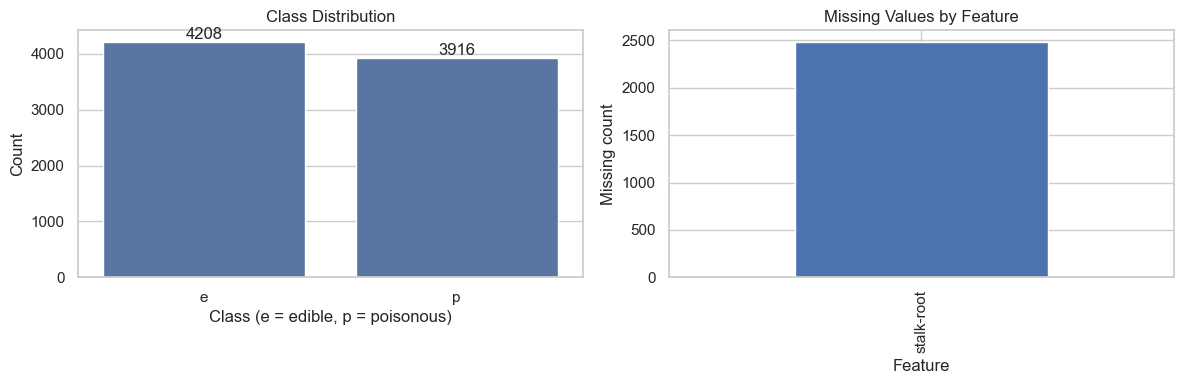

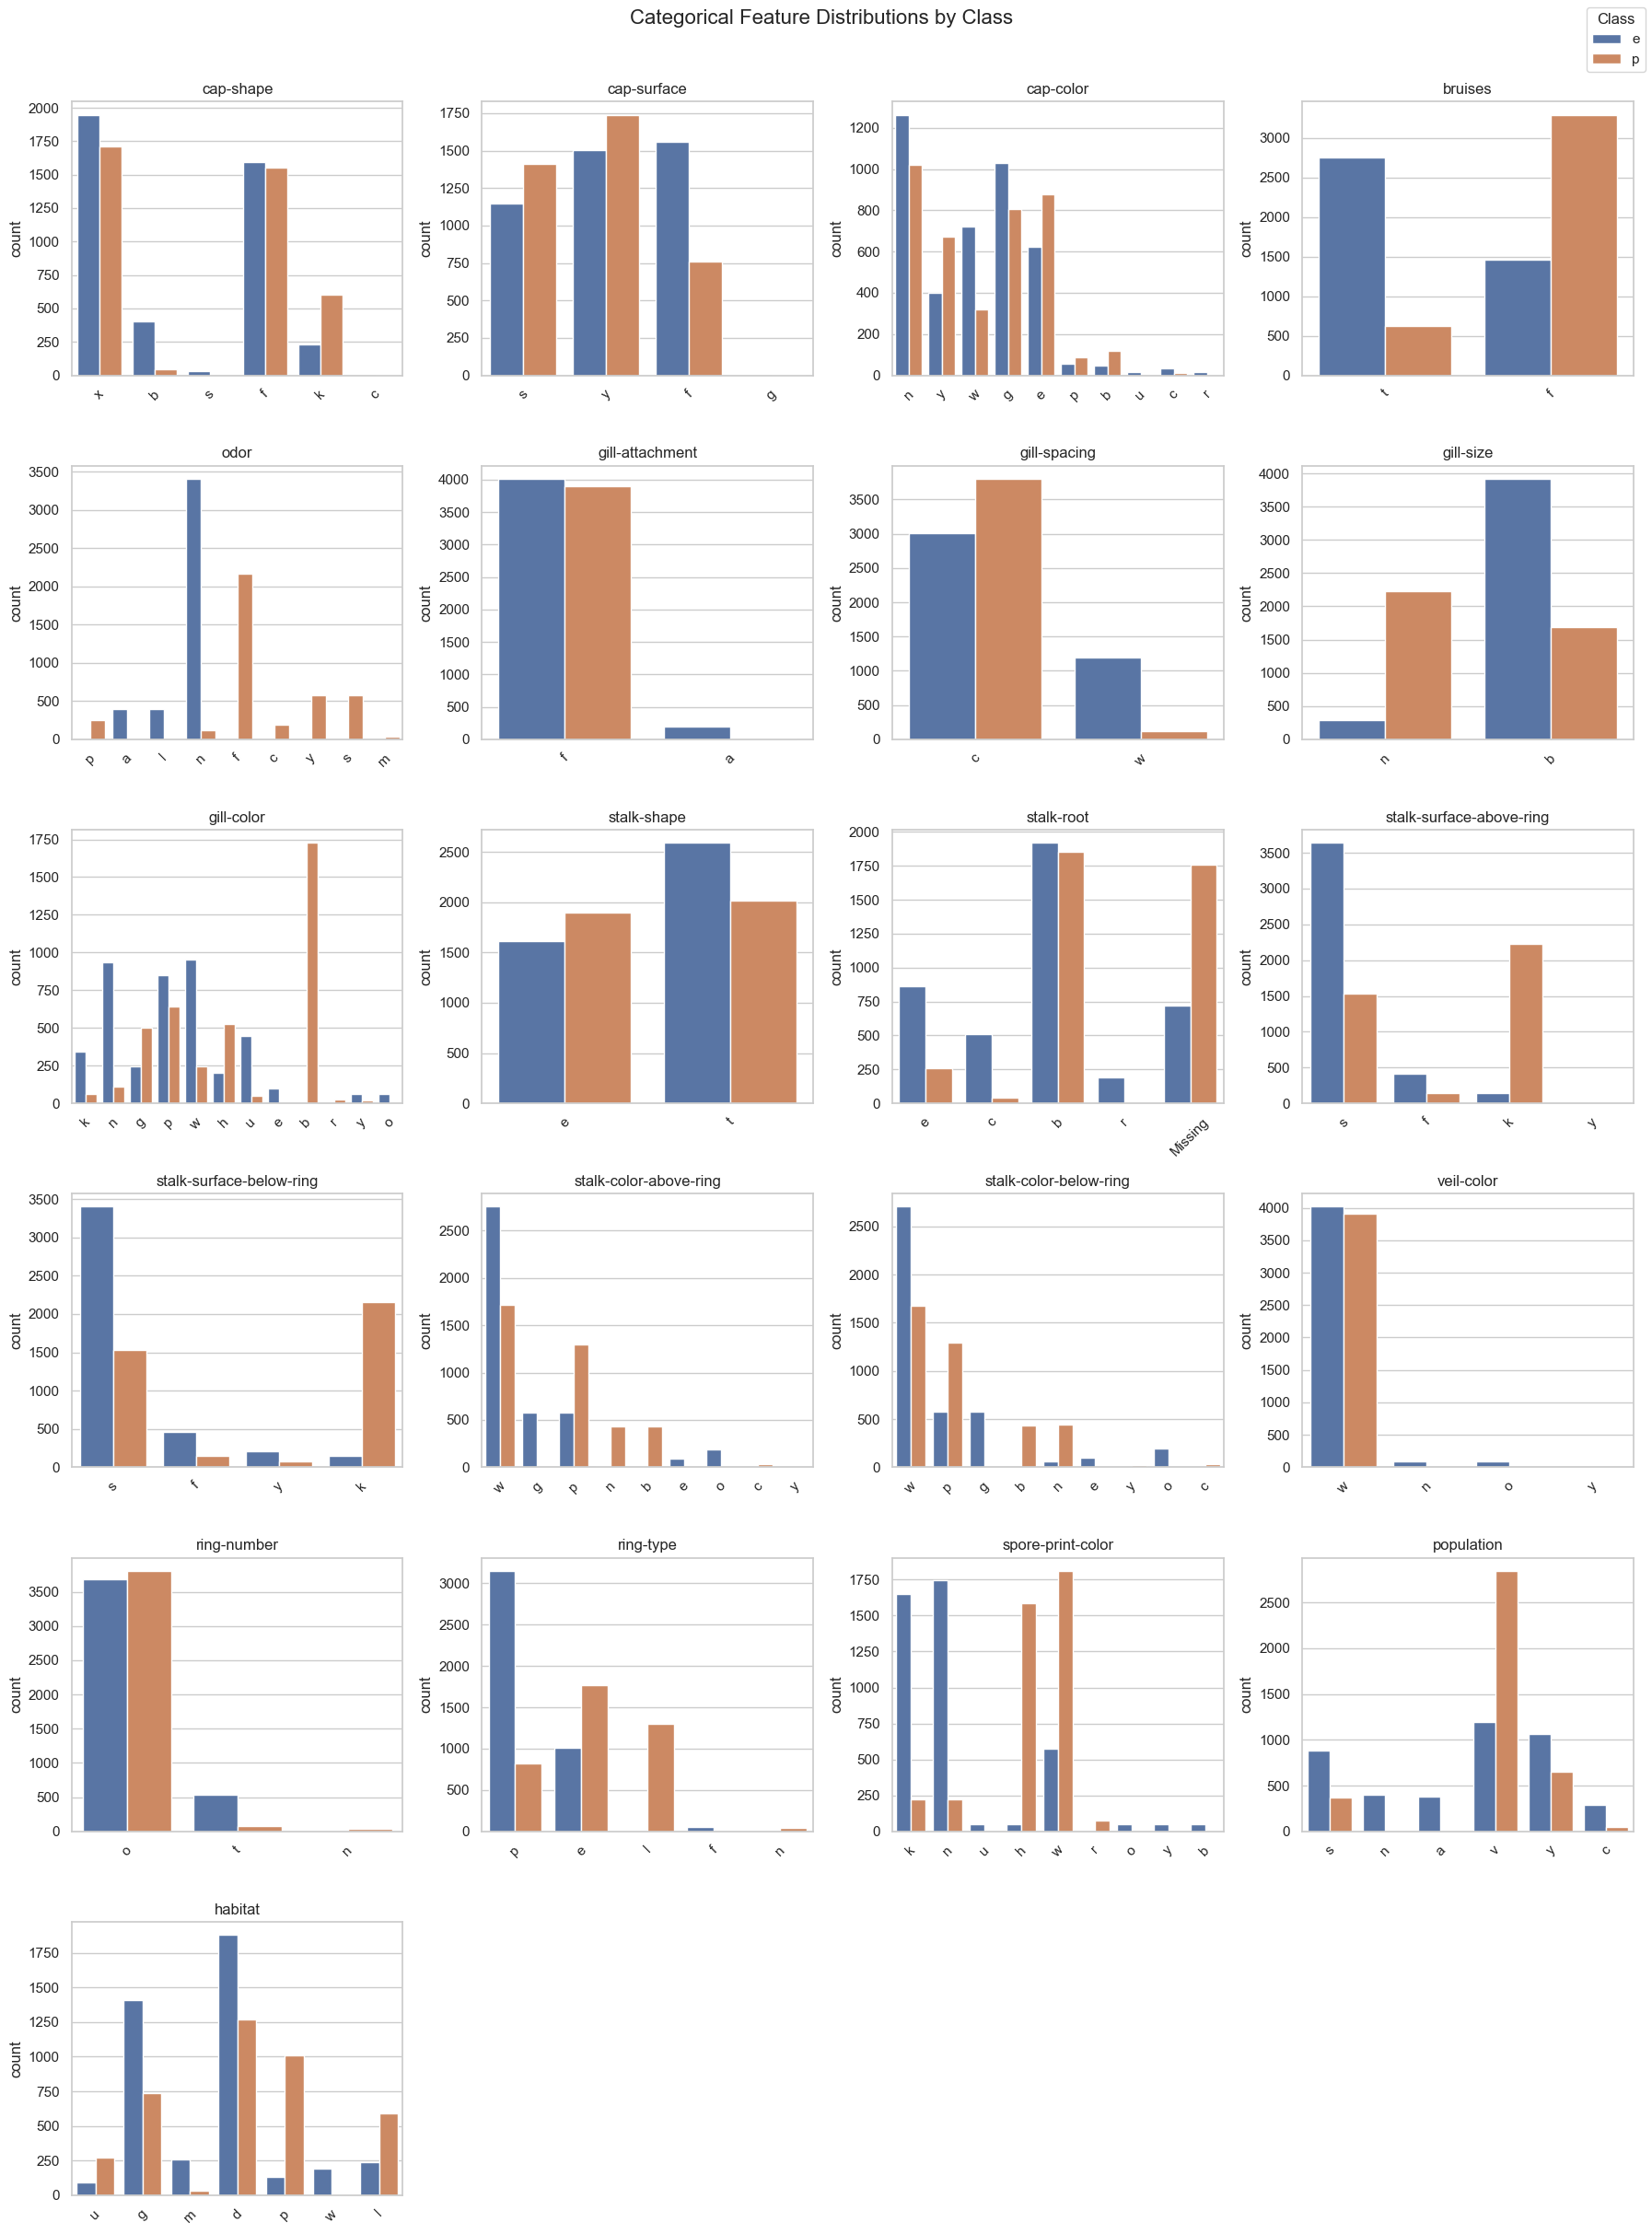

In [3]:
constant_columns = [c for c in feature_names if df[c].nunique(dropna=False) == 1]
assert constant_columns == ['veil-type']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='class', order=['e', 'p'], ax=axes[0], color='#4c72b0')
axes[0].set(title='Class Distribution', xlabel='Class (e = edible, p = poisonous)', ylabel='Count')
for container in axes[0].containers:
    axes[0].bar_label(container)
missing[missing.gt(0)].sort_values().plot.bar(ax=axes[1], color='#4c72b0')
axes[1].set(title='Missing Values by Feature', xlabel='Feature', ylabel='Missing count')
plt.tight_layout()
plt.show()

eda_features = [c for c in feature_names if c != 'veil-type']
fig, axes = plt.subplots(6, 4, figsize=(18, 24))
for ax, col in zip(axes.flat, eda_features):
    plot_data = df.assign(**{col: df[col].fillna('Missing')})
    sns.countplot(data=plot_data, x=col, hue='class', hue_order=['e', 'p'], ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    if ax.get_legend() is not None:
        ax.get_legend().remove()
for ax in axes.flat[len(eda_features):]:
    ax.set_visible(False)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Class', loc='upper right')
fig.suptitle('Categorical Feature Distributions by Class', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## 4. Stratified split and leakage-safe pipelines
Two preprocessing strategies are compared: an explicit `Missing` category and most-frequent imputation. Both then use one-hot encoding because the feature values are nominal rather than ordered.

In [4]:
X = df.drop(columns=['class', 'veil-type'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
assert set(X_train.index).isdisjoint(set(X_test.index))
assert len(X_train) + len(X_test) == len(df)

def make_pipeline(strategy, tree_params=None):
    if strategy == 'Explicit missing category':
        imputer = SimpleImputer(strategy='constant', fill_value='Missing')
    elif strategy == 'Most-frequent imputation':
        imputer = SimpleImputer(strategy='most_frequent')
    else:
        raise ValueError(f'Unknown strategy: {strategy}')
    preprocessor = ColumnTransformer([
        ('categorical', Pipeline([
            ('imputer', imputer),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), list(X.columns))
    ], remainder='drop')
    params = {'random_state': RANDOM_STATE}
    if tree_params:
        params.update(tree_params)
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', DecisionTreeClassifier(**params))
    ])

print(f'Training rows: {len(X_train):,}; test rows: {len(X_test):,}')
display(pd.crosstab(pd.Series(['train'] * len(y_train) + ['test'] * len(y_test), name='split'),
                    pd.concat([y_train, y_test], ignore_index=True), normalize='index').round(4))

Training rows: 6,499; test rows: 1,625


class,e,p
split,,
test,0.5182,0.4818
train,0.5179,0.4821


## 5. Baseline, manual, and tuned Decision Trees
The unrestricted baseline demonstrates the risk of overfitting. A manual depth-limited tree provides a simple comparison. Grid search then evaluates many Decision Tree configurations under five-fold stratified cross-validation.

Poisonous-class F1 is the primary metric. To resist overfitting, selection uses the one-standard-error rule: among models statistically close to the best cross-validation F1, choose the simplest tree (shallower depth, larger leaves, stronger split constraints, and more pruning). Poisonous recall and accuracy break any remaining tie.

In [5]:
poison_precision = make_scorer(precision_score, pos_label='p', zero_division=0)
poison_recall = make_scorer(recall_score, pos_label='p', zero_division=0)
poison_f1 = make_scorer(f1_score, pos_label='p', zero_division=0)
scoring = {'accuracy': 'accuracy', 'precision_p': poison_precision,
           'recall_p': poison_recall, 'f1_p': poison_f1}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def select_best_index(cv_results):
    f1_values = np.asarray(cv_results['mean_test_f1_p'])
    f1_std = np.asarray(cv_results['std_test_f1_p'])
    recall_values = np.asarray(cv_results['mean_test_recall_p'])
    accuracy_values = np.asarray(cv_results['mean_test_accuracy'])
    best_f1_idx = int(np.nanargmax(f1_values))
    standard_error = f1_std[best_f1_idx] / np.sqrt(CV_FOLDS)
    threshold = f1_values[best_f1_idx] - standard_error
    eligible = np.flatnonzero(f1_values >= threshold)

    def complexity_key(i):
        p = cv_results['params'][i]
        depth = p['model__max_depth'] if p['model__max_depth'] is not None else 10_000
        max_leaves = p['model__max_leaf_nodes'] if p['model__max_leaf_nodes'] is not None else 10_000
        return (
            depth,
            max_leaves,
            -p['model__min_samples_leaf'],
            -p['model__min_samples_split'],
            -p['model__ccp_alpha'],
            -recall_values[i],
            -accuracy_values[i]
        )
    return int(min(eligible, key=complexity_key))

param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 4, 5],
    'model__min_samples_split': [10, 20],
    'model__min_samples_leaf': [5, 10],
    'model__max_leaf_nodes': [8, 10, 12],
    'model__class_weight': [None],
    'model__ccp_alpha': [0.0005, 0.001, 0.005]
}
configurations_per_strategy = int(np.prod([len(v) for v in param_grid.values()]))
print(f'Grid candidates per preprocessing strategy: {configurations_per_strategy:,}')
print(f'Total CV fits for both strategies: {configurations_per_strategy * CV_FOLDS * 2:,}')

Grid candidates per preprocessing strategy: 216
Total CV fits for both strategies: 2,160


In [6]:
strategies = ['Explicit missing category', 'Most-frequent imputation']
manual_params = {'max_depth': 5, 'min_samples_leaf': 5, 'criterion': 'entropy'}
fitted_models, searches, rows = {}, {}, []

def metric_row(name, strategy, estimator, cv_scores=None, cv_f1=None, cv_recall=None, cv_accuracy=None):
    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)
    return {
        'variant': name, 'preprocessing': strategy,
        'train_accuracy': accuracy_score(y_train, train_pred),
        'cv_f1_poisonous': cv_f1 if cv_f1 is not None else np.mean(cv_scores['test_f1_p']),
        'cv_recall_poisonous': cv_recall if cv_recall is not None else np.mean(cv_scores['test_recall_p']),
        'cv_accuracy': cv_accuracy if cv_accuracy is not None else np.mean(cv_scores['test_accuracy']),
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_precision_poisonous': precision_score(y_test, test_pred, pos_label='p', zero_division=0),
        'test_recall_poisonous': recall_score(y_test, test_pred, pos_label='p', zero_division=0),
        'test_f1_poisonous': f1_score(y_test, test_pred, pos_label='p', zero_division=0),
        'tree_depth': estimator.named_steps['model'].get_depth(),
        'leaf_count': estimator.named_steps['model'].get_n_leaves()
    }

for strategy in strategies:
    for variant, params in [('Baseline', {}), ('Manual depth-limited', manual_params)]:
        pipe = make_pipeline(strategy, params)
        cv_scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
        pipe.fit(X_train, y_train)
        fitted_models[(strategy, variant)] = pipe
        rows.append(metric_row(variant, strategy, pipe, cv_scores=cv_scores))

    search = GridSearchCV(
        make_pipeline(strategy), param_grid=param_grid, scoring=scoring,
        refit=select_best_index, cv=cv, n_jobs=1, return_train_score=True, verbose=0
    )
    search.fit(X_train, y_train)
    searches[strategy] = search
    fitted_models[(strategy, 'GridSearchCV best')] = search.best_estimator_
    best_idx = search.best_index_
    rows.append(metric_row(
        'GridSearchCV best', strategy, search.best_estimator_,
        cv_f1=search.cv_results_['mean_test_f1_p'][best_idx],
        cv_recall=search.cv_results_['mean_test_recall_p'][best_idx],
        cv_accuracy=search.cv_results_['mean_test_accuracy'][best_idx]
    ))

results = pd.DataFrame(rows).sort_values(
    ['cv_f1_poisonous', 'cv_recall_poisonous', 'cv_accuracy'], ascending=False
).reset_index(drop=True)
display(results.style.format({c: '{:.4f}' for c in results.columns if c not in ['variant', 'preprocessing', 'tree_depth', 'leaf_count']}))

,variant,preprocessing,train_accuracy,cv_f1_poisonous,cv_recall_poisonous,cv_accuracy,test_accuracy,test_precision_poisonous,test_recall_poisonous,test_f1_poisonous,tree_depth,leaf_count
0,Baseline,Explicit missing category,1.0000,0.9997,0.9994,0.9997,1.0000,1.0000,1.0000,1.0000,7,14
1,Baseline,Most-frequent imputation,1.0000,0.9997,0.9994,0.9997,1.0000,1.0000,1.0000,1.0000,7,14
2,Manual depth-limited,Explicit missing category,1.0000,0.9992,0.9984,0.9992,1.0000,1.0000,1.0000,1.0000,5,11
3,Manual depth-limited,Most-frequent imputation,1.0000,0.9992,0.9984,0.9992,1.0000,1.0000,1.0000,1.0000,5,11
4,GridSearchCV best,Explicit missing category,0.9992,0.9989,0.9978,0.9989,0.9982,1.0000,0.9962,0.9981,5,10
5,GridSearchCV best,Most-frequent imputation,0.9992,0.9989,0.9978,0.9989,0.9982,1.0000,0.9962,0.9981,4,10


## 6. Final model evaluation
The final model is selected between the two tuned pipelines using training cross-validation only. The test metrics below are then reported once as an unbiased estimate of generalization.

Selected preprocessing: Explicit missing category
Selected parameters:


,value
model__ccp_alpha,0.001
model__class_weight,None
model__criterion,gini
model__max_depth,5
model__max_leaf_nodes,10
model__min_samples_leaf,10
model__min_samples_split,20


Classification report:
              precision    recall  f1-score   support

      edible     0.9964    1.0000    0.9982       842
   poisonous     1.0000    0.9962    0.9981       783

    accuracy                         0.9982      1625
   macro avg     0.9982    0.9981    0.9982      1625
weighted avg     0.9982    0.9982    0.9982      1625



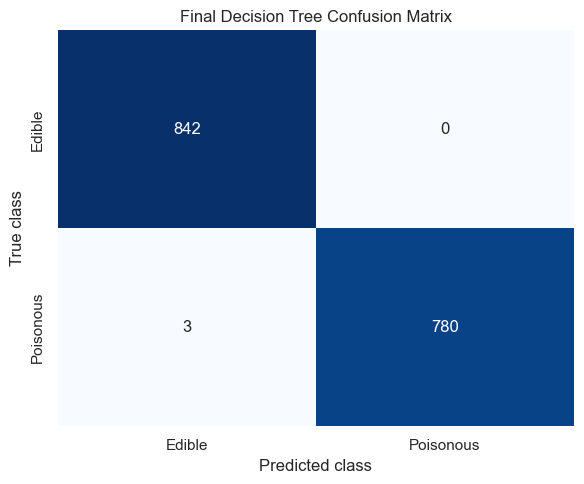

In [7]:
tuned_rows = results[results['variant'].eq('GridSearchCV best')].copy()
best_cv = tuned_rows['cv_f1_poisonous'].max()
final_row = tuned_rows.sort_values(
    ['cv_f1_poisonous', 'cv_recall_poisonous', 'cv_accuracy'], ascending=False
).iloc[0]
final_strategy = final_row['preprocessing']
final_search = searches[final_strategy]
final_model = final_search.best_estimator_
final_pred = final_model.predict(X_test)

assert isinstance(final_model.named_steps['model'], DecisionTreeClassifier)
assert len(final_pred) == len(y_test)
cm = confusion_matrix(y_test, final_pred, labels=['e', 'p'])
assert cm.sum() == len(y_test)

print('Selected preprocessing:', final_strategy)
print('Selected parameters:')
display(pd.Series(final_search.best_params_, name='value').to_frame())
print('Classification report:')
print(classification_report(y_test, final_pred, labels=['e', 'p'],
                            target_names=['edible', 'poisonous'], digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
ax.set(title='Final Decision Tree Confusion Matrix', xlabel='Predicted class', ylabel='True class')
plt.tight_layout()
plt.show()

## 7. Interpretation: depth, importance, and rules
A shallow rendering keeps the tree readable. Feature importances describe how much each encoded category reduced impurity; they show association, not causation.

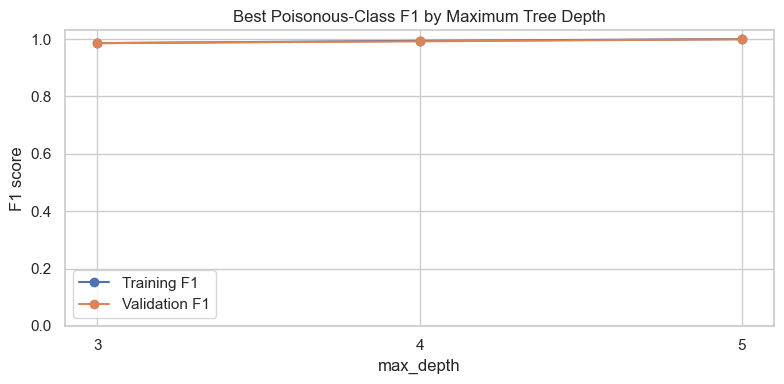

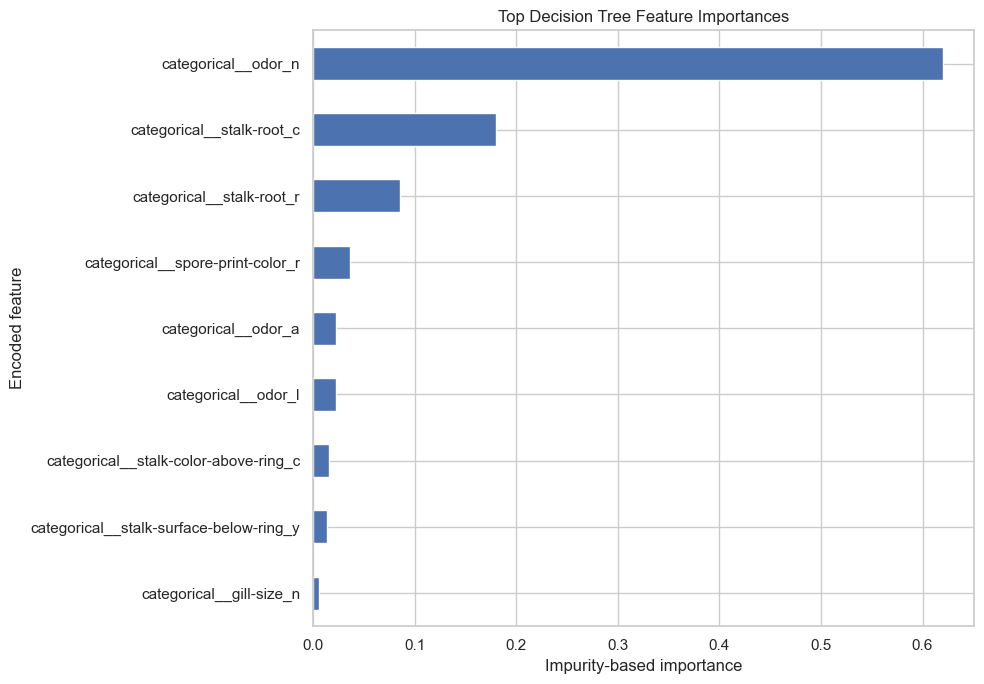

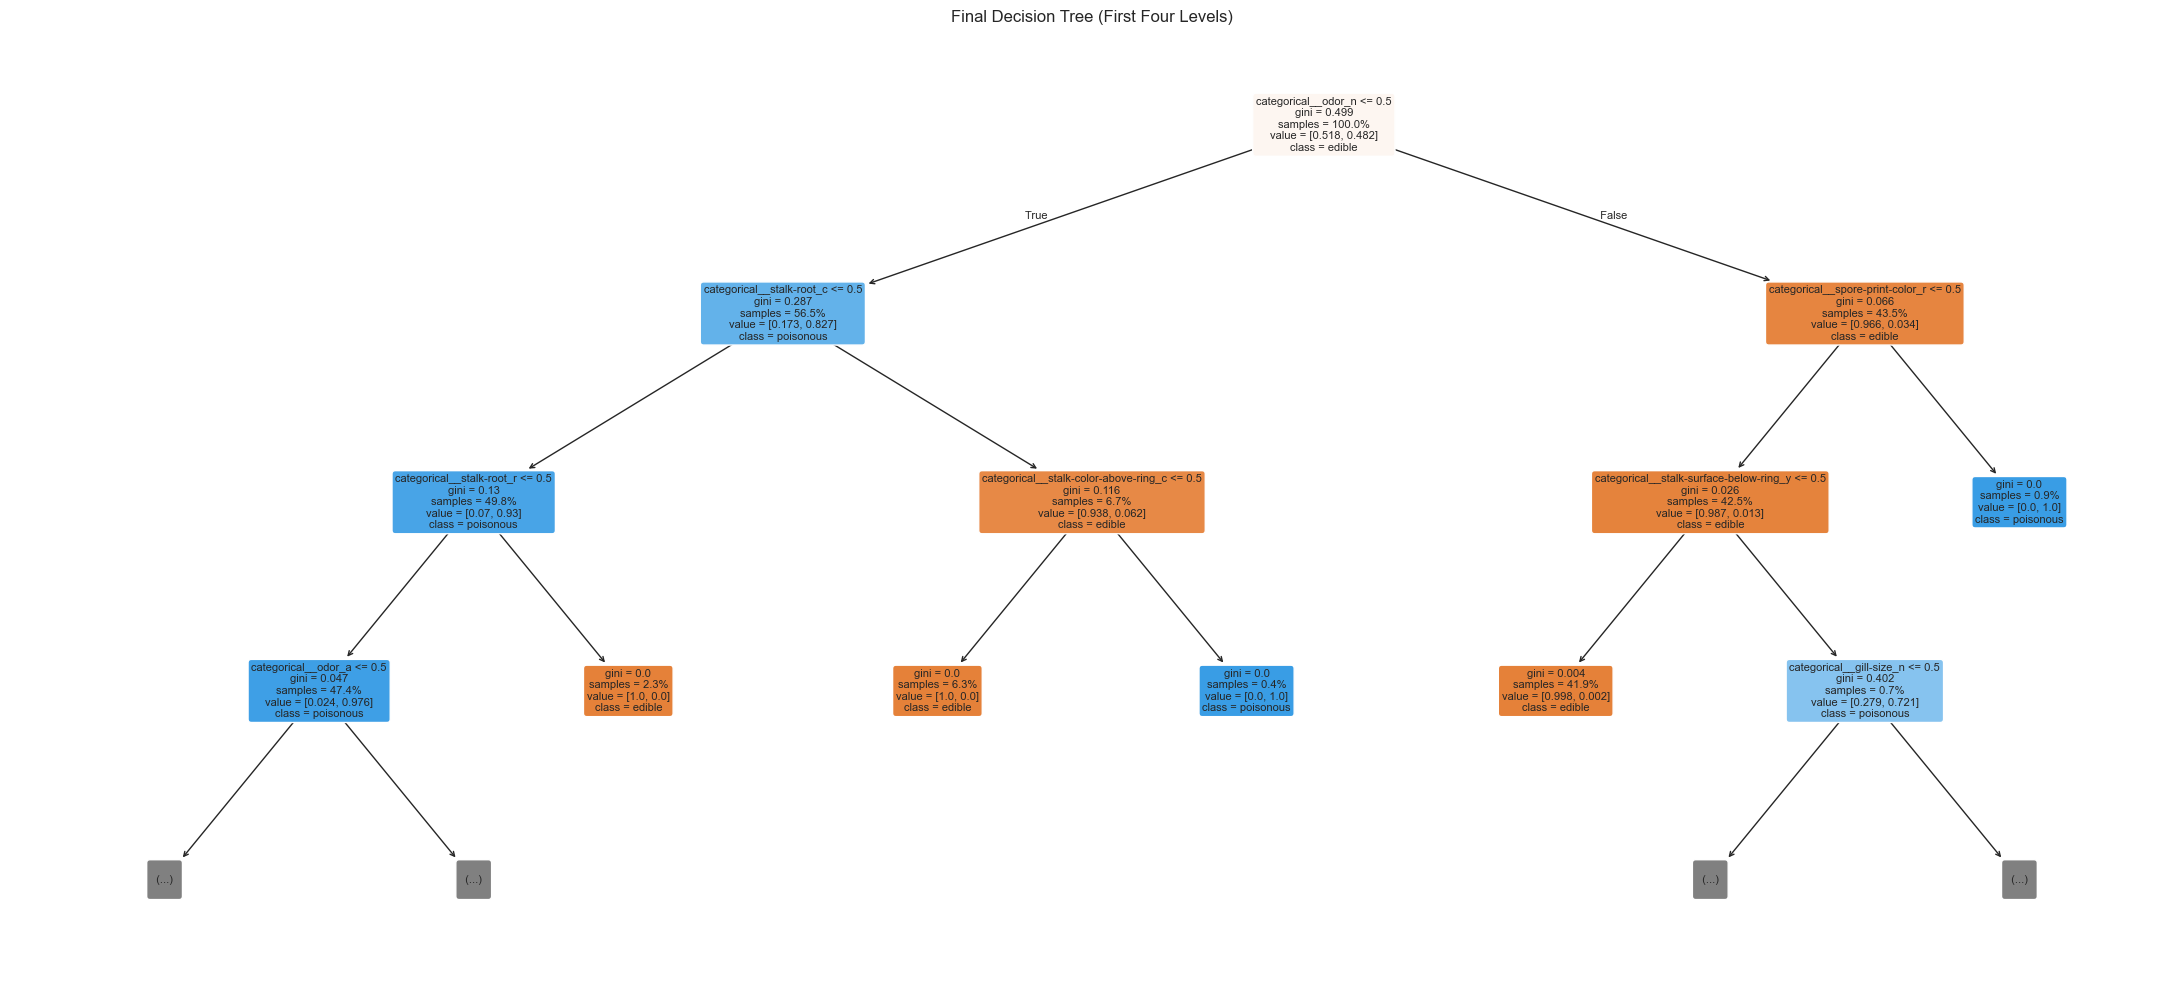

Readable rules (truncated to depth 4):
|--- categorical__odor_n <= 0.50
|   |--- categorical__stalk-root_c <= 0.50
|   |   |--- categorical__stalk-root_r <= 0.50
|   |   |   |--- categorical__odor_a <= 0.50
|   |   |   |   |--- categorical__odor_l <= 0.50
|   |   |   |   |   |--- class: p
|   |   |   |   |--- categorical__odor_l >  0.50
|   |   |   |   |   |--- class: e
|   |   |   |--- categorical__odor_a >  0.50
|   |   |   |   |--- class: e
|   |   |--- categorical__stalk-root_r >  0.50
|   |   |   |--- class: e
|   |--- categorical__stalk-root_c >  0.50
|   |   |--- categorical__stalk-color-above-ring_c <= 0.50
|   |   |   |--- class: e
|   |   |--- categorical__stalk-color-above-ring_c >  0.50
|   |   |   |--- class: p
|--- categorical__odor_n >  0.50
|   |--- categorical__spore-print-color_r <= 0.50
|   |   |--- categorical__stalk-surface-below-ring_y <= 0.50
|   |   |   |--- class: e
|   |   |--- categorical__stalk-surface-below-ring_y >  0.50
|   |   |   |--- categorical__gill-

In [8]:
cv_frame = pd.DataFrame(final_search.cv_results_)
depth_frame = cv_frame.assign(
    depth=cv_frame['param_model__max_depth'].astype(str)
).groupby('depth', as_index=False).agg(
    mean_cv_f1=('mean_test_f1_p', 'max'), mean_train_f1=('mean_train_f1_p', 'max')
)
depth_order = ['3', '4', '5']
depth_frame['depth'] = pd.Categorical(depth_frame['depth'], depth_order, ordered=True)
depth_frame = depth_frame.sort_values('depth')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depth_frame['depth'].astype(str), depth_frame['mean_train_f1'], marker='o', label='Training F1')
ax.plot(depth_frame['depth'].astype(str), depth_frame['mean_cv_f1'], marker='o', label='Validation F1')
ax.set(title='Best Poisonous-Class F1 by Maximum Tree Depth', xlabel='max_depth', ylabel='F1 score', ylim=(0, 1.03))
ax.legend()
plt.tight_layout()
plt.show()

preprocessor = final_model.named_steps['preprocess']
tree = final_model.named_steps['model']
encoded_names = preprocessor.get_feature_names_out()
importance = pd.Series(tree.feature_importances_, index=encoded_names).sort_values(ascending=False)
top_importance = importance[importance.gt(0)].head(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top_importance.plot.barh(ax=ax, color='#4c72b0')
ax.set(title='Top Decision Tree Feature Importances', xlabel='Impurity-based importance', ylabel='Encoded feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(22, 10))
plot_tree(tree, feature_names=encoded_names, class_names=['edible', 'poisonous'],
          filled=True, rounded=True, max_depth=3, fontsize=8, proportion=True)
plt.title('Final Decision Tree (First Four Levels)')
plt.tight_layout()
plt.show()

print('Readable rules (truncated to depth 4):')
print(export_text(tree, feature_names=list(encoded_names), max_depth=4, decimals=2))
print('Interpretation: each one-hot split asks whether a named category is absent (<= 0.5) or present (> 0.5).')

## 8. Export for the group comparison
This one-row CSV gives the group the optimum Decision Tree result and the information needed for its six-model comparison table.

In [9]:
group_summary = pd.DataFrame([{
    'student_model': 'Decision Tree',
    'preprocessing': final_strategy,
    'validation_method': f'{CV_FOLDS}-fold stratified cross-validation',
    'grid_candidates_per_strategy': configurations_per_strategy,
    'best_parameters': json.dumps(final_search.best_params_, sort_keys=True),
    'cv_f1_poisonous': float(final_search.cv_results_['mean_test_f1_p'][final_search.best_index_]),
    'train_accuracy': accuracy_score(y_train, final_model.predict(X_train)),
    'test_accuracy': accuracy_score(y_test, final_pred),
    'train_test_accuracy_gap': accuracy_score(y_train, final_model.predict(X_train)) - accuracy_score(y_test, final_pred),
    'test_precision_poisonous': precision_score(y_test, final_pred, pos_label='p', zero_division=0),
    'test_recall_poisonous': recall_score(y_test, final_pred, pos_label='p', zero_division=0),
    'test_f1_poisonous': f1_score(y_test, final_pred, pos_label='p', zero_division=0),
    'tree_depth': tree.get_depth(),
    'leaf_count': tree.get_n_leaves(),
    'limitation': 'Historical hypothetical-species data; not safe for real-world edibility decisions.'
}])
summary_path = OUTPUT_DIR / 'decision_tree_group_summary.csv'
group_summary.to_csv(summary_path, index=False)
model_path = OUTPUT_DIR / 'decision_tree_mushroom_pipeline.joblib'
joblib.dump(final_model, model_path)
display(group_summary.T)
print(f'Exported summary: {summary_path.resolve()}')
print(f'Exported fitted model: {model_path.resolve()}')

,0
student_model,Decision Tree
preprocessing,Explicit missing category
validation_method,5-fold stratified cross-validation
grid_candidates_per_strategy,216
best_parameters,"{""model__ccp_alpha"": 0.001, ""model__class_weig..."
cv_f1_poisonous,0.998881
train_accuracy,0.999231
test_accuracy,0.998154
train_test_accuracy_gap,0.001077
test_precision_poisonous,1.0


Exported summary: C:\Users\binuk\OneDrive\Desktop\AI Final BK\outputs\decision_tree_group_summary.csv
Exported fitted model: C:\Users\binuk\OneDrive\Desktop\AI Final BK\outputs\decision_tree_mushroom_pipeline.joblib


## 9. Viva notes, limitations, ethics, and reflection

### Viva demonstration order
1. Show the dataset validation and class balance.
2. Explain why `veil-type` is removed and why `stalk-root` needs missing-value handling.
3. Explain the leakage-safe pipelines and stratified split.
4. Compare the unrestricted and depth-limited trees.
5. Explain the grid, five-fold validation, and poisonous-class F1 selection.
6. Show the final confusion matrix, tree, feature importance, and readable rules.
7. State the limitations and safety warning.

### Limitations and improvements
- The records describe hypothetical samples from a limited set of gilled mushroom species; performance may not transfer to other species, regions, measurement practices, or real field observations.
- A single train-test split still has sampling uncertainty. Repeated nested cross-validation would give a stronger estimate but is outside this individual demonstration.
- One-hot feature importances can favor variables with many available splits and must not be interpreted causally.
- Future work could collect representative modern field data, audit subgroup errors, calibrate uncertainty, and involve qualified mycologists.

### Ethics and bias mitigation
A false edible prediction could cause severe harm. Poisonous recall is therefore reported prominently, preprocessing is leakage-safe, and the notebook includes an explicit warning against real-world consumption decisions. Dataset coverage limitations are disclosed instead of presenting high test performance as universal safety.

### AI tool usage declaration (edit to match your actual use)
Generative AI was used to help structure the notebook, explain code, and improve presentation. The student reviewed the dataset, executed and verified every cell, interpreted the results, and remains responsible for the submitted work. No AI-generated result was accepted without validation.

### Personal reflection prompt
Before submission, add your own short reflection describing what you learned about categorical preprocessing, tree overfitting, cross-validation, metric selection, and explaining model decisions. Do not submit a generic or AI-written reflection as personal experience.

### References
- UCI Machine Learning Repository, Mushroom dataset and accompanying metadata.
- scikit-learn documentation: `DecisionTreeClassifier`, `Pipeline`, `OneHotEncoder`, and `GridSearchCV`.